In [311]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [312]:
df = pd.read_csv('/Users/ximenamarin/Desktop/LIT/extracción de datos/Regresion_lineal/Acticidad5.1/Analisis GAC Full7agosto 2026(Leads Reales).csv', skiprows=2)

In [313]:
df.head(5)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [314]:
df.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion ',
       'Efectividad de Leads', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='str')

In [315]:
df1 = df.iloc[:29, :11]

In [316]:
df1.head(5)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%


In [317]:
valores_nulos=df1.isnull().sum()
valores_nulos

Año               26
Mes                0
Total              1
Ilocalizable       1
No Contesta        1
D. Incorrectos     1
Duplicados         1
Efectivos          1
Abiertos           1
Ventas             1
Conversion         1
dtype: int64

In [318]:
df1.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion '],
      dtype='str')

In [319]:
df1[['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion ']] = df1[['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion ']].fillna(0) 
df1.head(5)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,Enero,0,0,0,0,0,0,0,0,0
1,0.0,Febrero,543,108,33,0,1,389,1,12,3.1%
2,0.0,Marzo,178,37,13,0,0,128,1,7,5.5%
3,0.0,Abril,416,79,46,3,0,288,1,8,2.8%
4,0.0,Mayo,422,33,100,17,0,274,5,13,4.7%


In [320]:
df1.dtypes

Año               float64
Mes                   str
Total              object
Ilocalizable       object
No Contesta        object
D. Incorrectos     object
Duplicados         object
Efectivos          object
Abiertos           object
Ventas             object
Conversion         object
dtype: object

In [321]:
data = df1.copy()

In [322]:
data.loc[1:12, 'Año'] = 2024

In [323]:
data.loc[12:24, 'Año'] = 2025

In [324]:
data.loc[24:, 'Año'] = 2026

In [325]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,Enero,0,0,0,0,0,0,0,0,0
1,2024.0,Febrero,543,108,33,0,1,389,1,12,3.1%
2,2024.0,Marzo,178,37,13,0,0,128,1,7,5.5%
3,2024.0,Abril,416,79,46,3,0,288,1,8,2.8%
4,2024.0,Mayo,422,33,100,17,0,274,5,13,4.7%
5,2024.0,Junio,967,140,173,31,3,620,17,6,1.0%
6,2024.0,Julio,954,112,251,12,9,570,5,21,3.7%
7,2024.0,Agosto,"1,409",504,324,17,18,546,22,17,3.1%
8,2024.0,Septiembre,"1,315",431,314,14,26,530,42,17,3.2%
9,2024.0,Octubre,"1,973",514,606,18,13,822,72,23,2.8%


In [326]:
data.dtypes

Año               float64
Mes                   str
Total              object
Ilocalizable       object
No Contesta        object
D. Incorrectos     object
Duplicados         object
Efectivos          object
Abiertos           object
Ventas             object
Conversion         object
dtype: object

In [327]:
# Convertimos a texto, eliminamos espacios y unificamos la escritura
data['Mes'] = data['Mes'].astype(str).str.strip().str.capitalize()

# Revisamos cómo quedaron
data['Mes'].unique()

<StringArray>
[     'Enero',    'Febrero',      'Marzo',      'Abril',       'Mayo',
      'Junio',      'Julio',     'Agosto', 'Septiembre',    'Octubre',
  'Noviembre',  'Diciembre']
Length: 12, dtype: str

In [328]:
meses = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12
}

data['Mes'] = data['Mes'].map(meses)

In [329]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,1,0,0,0,0,0,0,0,0,0
1,2024.0,2,543,108,33,0,1,389,1,12,3.1%
2,2024.0,3,178,37,13,0,0,128,1,7,5.5%
3,2024.0,4,416,79,46,3,0,288,1,8,2.8%
4,2024.0,5,422,33,100,17,0,274,5,13,4.7%
5,2024.0,6,967,140,173,31,3,620,17,6,1.0%
6,2024.0,7,954,112,251,12,9,570,5,21,3.7%
7,2024.0,8,"1,409",504,324,17,18,546,22,17,3.1%
8,2024.0,9,"1,315",431,314,14,26,530,42,17,3.2%
9,2024.0,10,"1,973",514,606,18,13,822,72,23,2.8%


In [330]:
#quitamos el porcentaje para volverlo un valor numérico
data['Conversion '] = data['Conversion '].str.rstrip('%').astype(float)

In [331]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,1,0,0,0,0,0,0,0,0,NaN
1,2024.0,2,543,108,33,0,1,389,1,12,3.1
2,2024.0,3,178,37,13,0,0,128,1,7,5.5
3,2024.0,4,416,79,46,3,0,288,1,8,2.8
4,2024.0,5,422,33,100,17,0,274,5,13,4.7
5,2024.0,6,967,140,173,31,3,620,17,6,1.0
6,2024.0,7,954,112,251,12,9,570,5,21,3.7
7,2024.0,8,"1,409",504,324,17,18,546,22,17,3.1
8,2024.0,9,"1,315",431,314,14,26,530,42,17,3.2
9,2024.0,10,"1,973",514,606,18,13,822,72,23,2.8


In [332]:
#quitamos la coma en totales para volverlo un valor numérico
data['Total'] = data['Total'].str.replace(',', '').astype(float)

In [333]:
#quitamos la coma de efectivos para volverlo un valor numérico
data['Efectivos'] = data['Efectivos'].str.replace(',', '').astype(float)

In [334]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,1,NaN,0,0,0,0,NaN,0,0,NaN
1,2024.0,2,543.0,108,33,0,1,389.0,1,12,3.1
2,2024.0,3,178.0,37,13,0,0,128.0,1,7,5.5
3,2024.0,4,416.0,79,46,3,0,288.0,1,8,2.8
4,2024.0,5,422.0,33,100,17,0,274.0,5,13,4.7
5,2024.0,6,967.0,140,173,31,3,620.0,17,6,1.0
6,2024.0,7,954.0,112,251,12,9,570.0,5,21,3.7
7,2024.0,8,1409.0,504,324,17,18,546.0,22,17,3.1
8,2024.0,9,1315.0,431,314,14,26,530.0,42,17,3.2
9,2024.0,10,1973.0,514,606,18,13,822.0,72,23,2.8


In [335]:
#Pasar todas las columnas a tipo numerico
data = data.apply(pd.to_numeric, errors='coerce')

In [336]:
data.dtypes

Año               float64
Mes                 int64
Total             float64
Ilocalizable        int64
No Contesta         int64
D. Incorrectos      int64
Duplicados          int64
Efectivos         float64
Abiertos            int64
Ventas              int64
Conversion        float64
dtype: object

In [337]:
#volemos a 0 los NA
data = data.fillna(0)

In [338]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,1,0.0,0,0,0,0,0.0,0,0,0.0
1,2024.0,2,543.0,108,33,0,1,389.0,1,12,3.1
2,2024.0,3,178.0,37,13,0,0,128.0,1,7,5.5
3,2024.0,4,416.0,79,46,3,0,288.0,1,8,2.8
4,2024.0,5,422.0,33,100,17,0,274.0,5,13,4.7
5,2024.0,6,967.0,140,173,31,3,620.0,17,6,1.0
6,2024.0,7,954.0,112,251,12,9,570.0,5,21,3.7
7,2024.0,8,1409.0,504,324,17,18,546.0,22,17,3.1
8,2024.0,9,1315.0,431,314,14,26,530.0,42,17,3.2
9,2024.0,10,1973.0,514,606,18,13,822.0,72,23,2.8


In [339]:
data.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion '],
      dtype='str')

<Axes: xlabel='Ventas', ylabel='Total'>

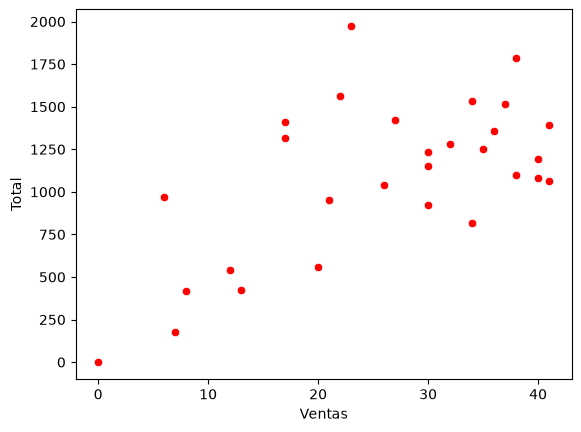

In [340]:
from turtle import color
sns.scatterplot(x='Ventas', y='Total', color="red", data=data)

In [341]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= data[['Ventas']]
Var_Dep= data['Total']

In [342]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [343]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [344]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[24.07]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Ventas']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,457.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [345]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Ventas'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([24.06909481]),
 'rank_': np.int64(1),
 'singular_': array([63.39531148]),
 'intercept_': np.float64(457.5114972114974)}

In [235]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.3864845579529278

In [346]:
y_pred= model.predict(X=data[['Ventas']])
y_pred

array([ 457.51149721,  746.34063492,  625.99516088,  650.06425568,
        770.40972973,  601.92606607,  962.9624882 ,  866.68610897,
        866.68610897, 1011.10067782,  987.03158301, 1227.7225311 ,
       1083.30796225,  938.89339339, 1179.58434148, 1179.58434148,
       1275.86072072, 1420.27528958, 1323.99891034, 1107.37705706,
       1372.13709996, 1420.27528958, 1444.34438438, 1275.86072072,
       1348.06800515, 1179.58434148, 1372.13709996, 1444.34438438,
       1299.92981553])

In [347]:
#Insertamos la columna de predicciones en el DataFrame
data.insert(0, 'Predicciones', y_pred)
data

,Predicciones,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,457.511497,2024.0,1,0.0,0,0,0,0,0.0,0,0,0.0
1,746.340635,2024.0,2,543.0,108,33,0,1,389.0,1,12,3.1
2,625.995161,2024.0,3,178.0,37,13,0,0,128.0,1,7,5.5
3,650.064256,2024.0,4,416.0,79,46,3,0,288.0,1,8,2.8
4,770.409730,2024.0,5,422.0,33,100,17,0,274.0,5,13,4.7
5,601.926066,2024.0,6,967.0,140,173,31,3,620.0,17,6,1.0
6,962.962488,2024.0,7,954.0,112,251,12,9,570.0,5,21,3.7
7,866.686109,2024.0,8,1409.0,504,324,17,18,546.0,22,17,3.1
8,866.686109,2024.0,9,1315.0,431,314,14,26,530.0,42,17,3.2
9,1011.100678,2024.0,10,1973.0,514,606,18,13,822.0,72,23,2.8


<Axes: xlabel='Ventas', ylabel='Total'>

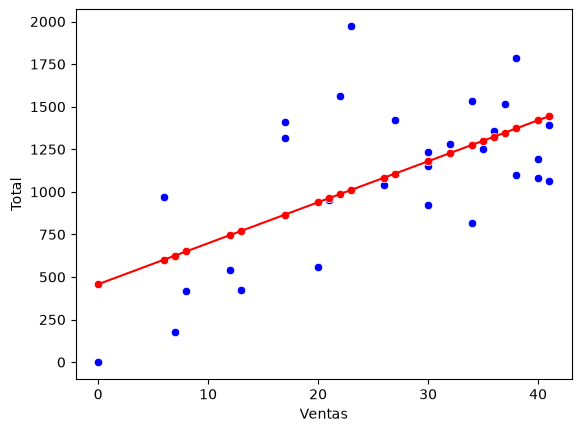

In [349]:
sns.scatterplot(x='Ventas', y='Total', color="blue", data=data)
sns.scatterplot(x='Ventas', y='Predicciones', color="red", data=data)
sns.lineplot(x='Ventas', y='Predicciones', color="red", data=data)

In [350]:
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.3864845579529278

In [351]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.6216788221846774)

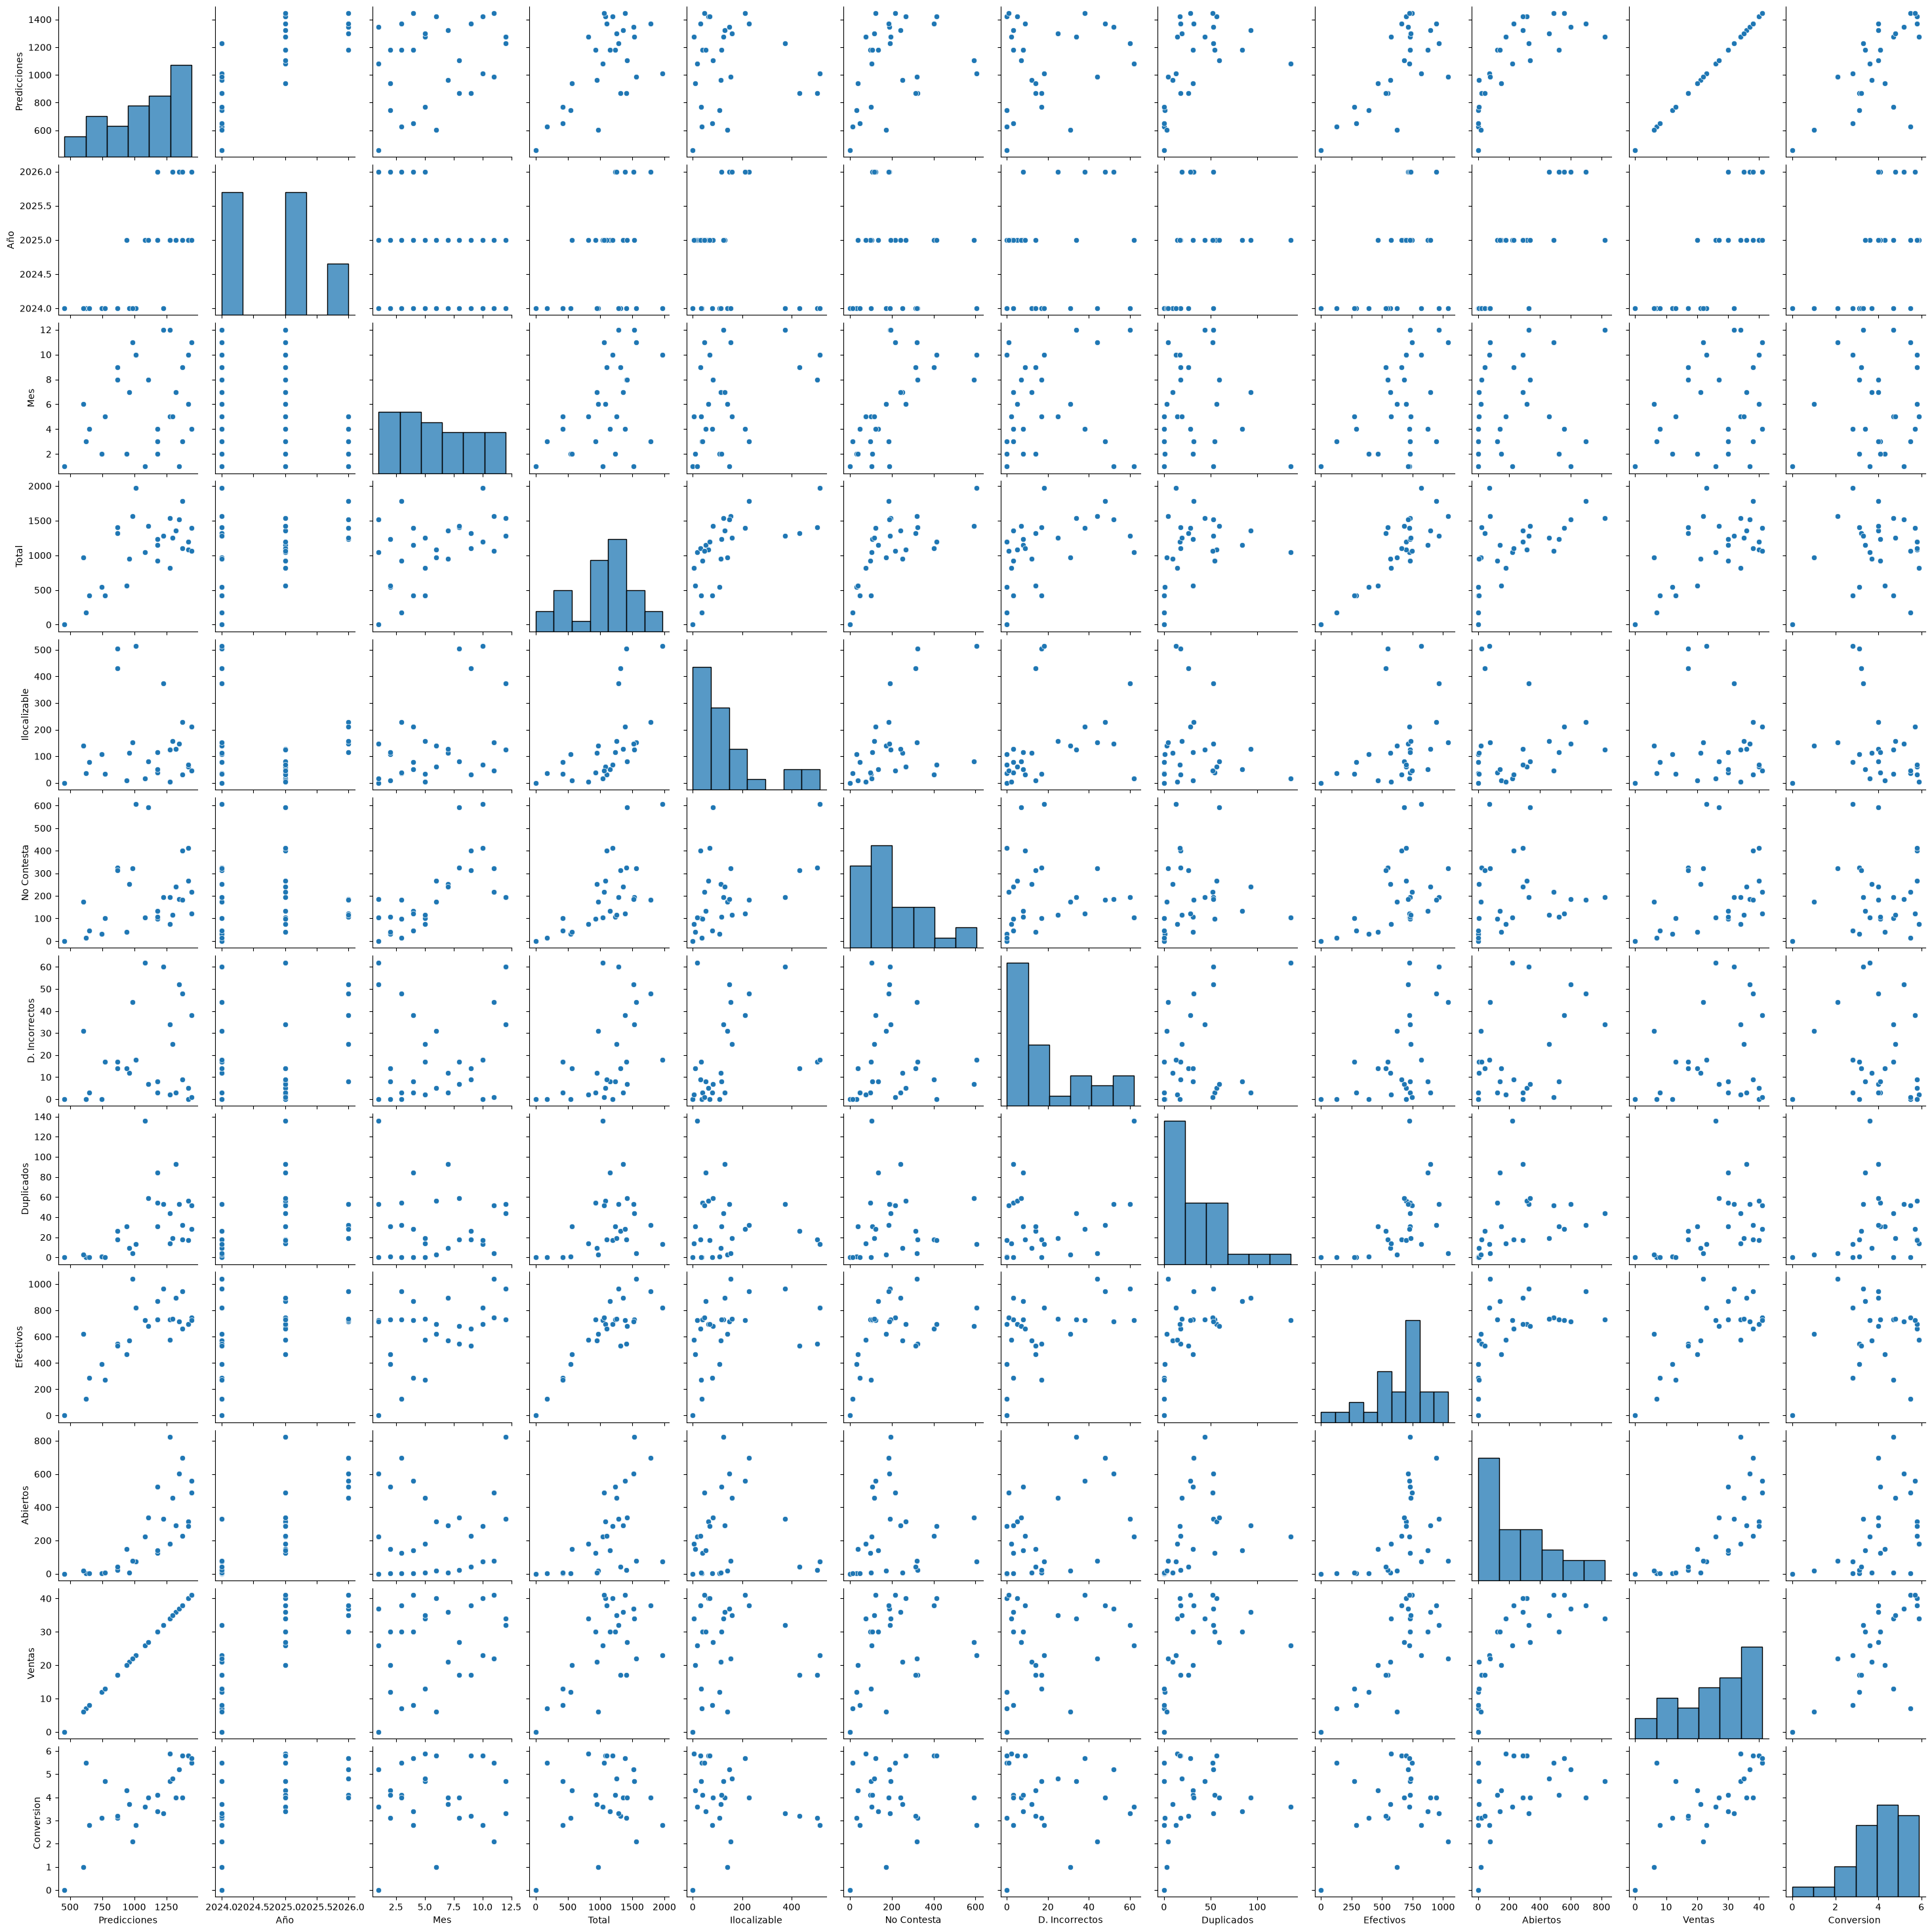

In [352]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(data)

In [353]:
#Encontramos todas las correlaciones entre las variables 
Corr_Factors=data.corr()
Corr_Factors

,Predicciones,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
Predicciones,1.000000,0.746773,0.273725,0.621679,-0.018107,0.297785,0.205243,0.483363,0.724746,0.752456,1.000000,0.704297
Año,0.746773,1.000000,-0.298181,0.390258,-0.220409,-0.075146,0.210277,0.396225,0.427469,0.808063,0.746773,0.550205
Mes,0.273725,-0.298181,1.000000,0.479697,0.422512,0.665231,0.050075,-0.076695,0.431038,0.103614,0.273725,0.079185
Total,0.621679,0.390258,0.479697,1.000000,0.599487,0.669922,0.480309,0.316184,0.853120,0.551099,0.621679,0.137652
Ilocalizable,-0.018107,-0.220409,0.422512,0.599487,1.000000,0.468315,0.317660,-0.120466,0.302049,-0.009711,-0.018107,-0.246187
No Contesta,0.297785,-0.075146,0.665231,0.669922,0.468315,1.000000,0.007697,0.060173,0.446789,0.061847,0.297785,0.060263
D. Incorrectos,0.205243,0.210277,0.050075,0.480309,0.317660,0.007697,1.000000,0.312636,0.489818,0.404663,0.205243,-0.108454
Duplicados,0.483363,0.396225,-0.076695,0.316184,-0.120466,0.060173,0.312636,1.000000,0.493905,0.361791,0.483363,0.174691
Efectivos,0.724746,0.427469,0.431038,0.853120,0.302049,0.446789,0.489818,0.493905,1.000000,0.518063,0.724746,0.169412
Abiertos,0.752456,0.808063,0.103614,0.551099,-0.009711,0.061847,0.404663,0.361791,0.518063,1.000000,0.752456,0.474647


In [354]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables 
Corr_Factors1= abs(Corr_Factors)
Corr_Factors1

,Predicciones,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
Predicciones,1.000000,0.746773,0.273725,0.621679,0.018107,0.297785,0.205243,0.483363,0.724746,0.752456,1.000000,0.704297
Año,0.746773,1.000000,0.298181,0.390258,0.220409,0.075146,0.210277,0.396225,0.427469,0.808063,0.746773,0.550205
Mes,0.273725,0.298181,1.000000,0.479697,0.422512,0.665231,0.050075,0.076695,0.431038,0.103614,0.273725,0.079185
Total,0.621679,0.390258,0.479697,1.000000,0.599487,0.669922,0.480309,0.316184,0.853120,0.551099,0.621679,0.137652
Ilocalizable,0.018107,0.220409,0.422512,0.599487,1.000000,0.468315,0.317660,0.120466,0.302049,0.009711,0.018107,0.246187
No Contesta,0.297785,0.075146,0.665231,0.669922,0.468315,1.000000,0.007697,0.060173,0.446789,0.061847,0.297785,0.060263
D. Incorrectos,0.205243,0.210277,0.050075,0.480309,0.317660,0.007697,1.000000,0.312636,0.489818,0.404663,0.205243,0.108454
Duplicados,0.483363,0.396225,0.076695,0.316184,0.120466,0.060173,0.312636,1.000000,0.493905,0.361791,0.483363,0.174691
Efectivos,0.724746,0.427469,0.431038,0.853120,0.302049,0.446789,0.489818,0.493905,1.000000,0.518063,0.724746,0.169412
Abiertos,0.752456,0.808063,0.103614,0.551099,0.009711,0.061847,0.404663,0.361791,0.518063,1.000000,0.752456,0.474647


<Axes: >

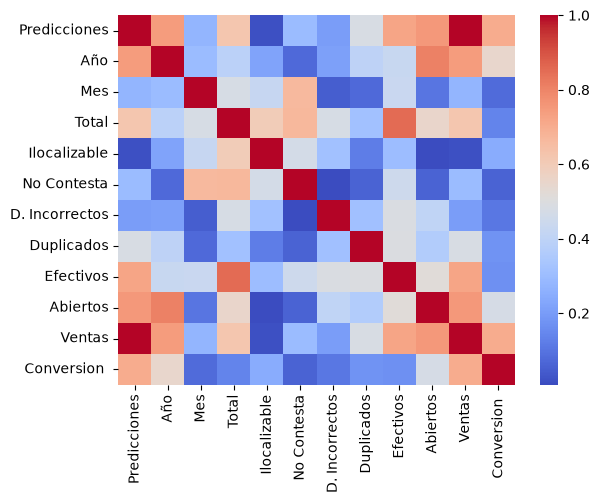

In [355]:
 #Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'coolwarm')  
Heat_Map

<Axes: >

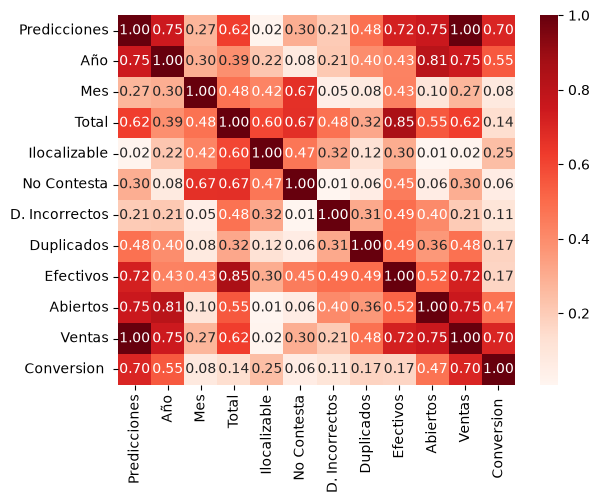

In [356]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'Reds', annot=True, fmt=".2f")  
Heat_Map